# Plotting global mortality timeseries per 100k due to surface ozone exposure

Using CESM2, SSP2-4.5 ensemble member 1 as an example

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import autosize_figure, get_scenario_config
import config
from utils.utils import require_dir
import pathlib

In [2]:
def process_mortality_per_100k(model, scenario, GBD_version, years, ens_num, n_samples):
    dates = f"{years.start}-{years.stop - 1}"

    # === Load data ===
    DIR = require_dir(pathlib.Path(config.WORK_ROOT) / model / "mortality" / "ozone")
    file = f"Global_mortality_{GBD_version}_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
    path = os.path.join(DIR, file)
    da = xr.open_dataarray(path)

    # Load population
    POP_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "SSP_pop" / "SSP2")
    pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    population = xr.open_dataarray(pop_path)

    global_pop = population.sum(dim=("lat", "lon"))

    data_per100k = (da/global_pop)*100000

    return data_per100k

In [3]:
def plotting_data(da, q1, q2):
    mean = da.mean("samples")
    p1 = da.quantile(q1, "samples")
    p2 = da.quantile(q2, "samples")
    return mean, p1, p2

In [4]:
def plot_global_mortality(da, years, model, scenario, GBD_version, ens_num, q1, q2, label):
    dates = f"{years.start}-{years.stop - 1}"

    da_mean, da_p1, da_p2 = plotting_data(da, q1, q2)

    plt.rcParams.update({'font.size': 16})

    color = "#FEA571"

    plt.figure(figsize=autosize_figure(1, 1))
    plt.plot(da["year"], da_mean, color=color, label="mean")
    plt.fill_between(da["year"], da_p1, da_p2, color=color, alpha=0.4, label=label)

    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.2)
    plt.ylabel("Global COPD mortality per 100,000")
    plt.legend(
        frameon=True,
        facecolor="white",
        edgecolor="none",
        framealpha=0.8
    )

    plt.title(f"{model} {scenario} ensemble {ens_num}")

    out_file = f"Global_ozone_mortality_per100k_{GBD_version}_{model}_{scenario}_{dates}.png"
    out_path = os.path.join(SAVE_DIR, out_file)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    return

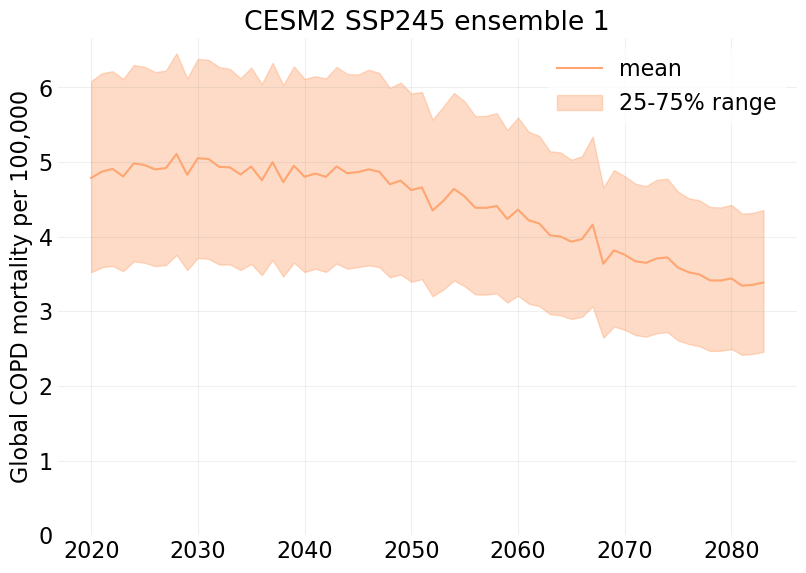

In [5]:
# === Path Config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "example_workflow")

model = "CESM2"
scenario = "SSP245"
GBD_version = "GBD23"
ensemble_number = 1

configs = get_scenario_config(model, scenario)
years = configs["years"]

n_samples = 300

da_100k = process_mortality_per_100k(model, scenario, GBD_version, years, ensemble_number, n_samples)

# Quantiles for plotting uncertainty
q1 = 0.25
q2 = 0.75
label = "25-75% range"

plot_global_mortality(da_100k, years, model, scenario, GBD_version, ensemble_number, q1, q2, label)